#TRANSFORMER ENCODER FOR SENTIMENT CLASSIFICATION
---

##0.REFERENCE, CONTEXT AND A SMOKE TEST

##0.1.CONTEXT

**Introduction**

The Transformer architecture represents one of the most important breakthroughs in the history of artificial intelligence. Modern systems such as GPT, Claude, Gemini, Llama, and Mistral all derive from the Transformer family of models introduced in the landmark paper *Attention Is All You Need*. Unlike recurrent neural networks, which process information sequentially, Transformers process entire sequences simultaneously through the mechanism of self-attention. This enables significantly greater parallelism, improved scalability, and the ability to capture long-range contextual dependencies.

In previous chapters of this Machine Learning Laboratory series, students learned Deep Neural Networks, Embeddings, Convolutional Neural Networks, Long Short-Term Memory Networks, Autoencoders, Variational Autoencoders, and Generative Adversarial Networks. Each of these architectures solved specific classes of problems. Transformers, however, have emerged as a general-purpose architecture capable of handling language, images, code, reasoning, and multimodal data.

This notebook introduces Transformers through a practical sentiment classification problem. The objective is to classify movie reviews as either positive or negative using the IMDB dataset. Rather than building a Transformer from scratch, we will use DistilBERT, a compressed version of BERT that preserves most of its performance while significantly reducing computational requirements. DistilBERT is widely used in education and industry because it provides a realistic Transformer architecture that can be fine-tuned efficiently on commodity hardware such as Google Colab.

The notebook follows a transfer-learning paradigm. Instead of training a Transformer from random initialization, we begin with a model that has already learned linguistic structure from massive text corpora. Fine-tuning adapts this pretrained knowledge to a specific downstream task. This approach reflects how most modern AI systems are developed in practice.

Students will learn how text is tokenized, how Transformer models receive input, how fine-tuning is performed, and how predictions are generated. The notebook also includes visualizations of training performance, embedding representations, and model predictions. A GPT-5.2 explanation cell provides a governed interpretation of results, separating facts, assumptions, limitations, and recommendations.

By the end of this chapter, students will understand how a real Transformer model is applied to a practical machine learning task. More importantly, they will gain experience with the Hugging Face ecosystem, which has become the standard platform for modern natural language processing research and deployment.

##0.2.SMOKE TEST OF DISTILBERT

In [1]:
# ============================================================
# CHAPTER 9 DISTILBERT COMPLETE SMOKE TEST
# Transformer Encoder with DistilBERT + IMDB
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL PACKAGES
# ------------------------------------------------------------

!pip -q install -U transformers datasets evaluate accelerate scikit-learn

# ------------------------------------------------------------
# 2. IMPORTS
# ------------------------------------------------------------

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# 3. REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 4. ENVIRONMENT CHECK
# ------------------------------------------------------------

print("=" * 80)
print("ENVIRONMENT CHECK")
print("=" * 80)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ------------------------------------------------------------
# 5. ARTIFACT FOLDERS
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/distilbert_smoke_test")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)

# ------------------------------------------------------------
# 6. LOAD DATASET
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

# Keep the smoke test tiny.
# This is only to verify the pipeline, not to train the chapter model.

train_small = (
    dataset["train"]
    .shuffle(seed=SEED)
    .select(range(64))
)

eval_small = (
    dataset["test"]
    .shuffle(seed=SEED)
    .select(range(32))
)

print("Train small:", train_small)
print("Eval small:", eval_small)

# ------------------------------------------------------------
# 7. LOAD TOKENIZER
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING TOKENIZER")
print("=" * 80)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded:", MODEL_NAME)

# ------------------------------------------------------------
# 8. TOKENIZATION FUNCTION
# ------------------------------------------------------------

MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

train_tokenized = train_small.map(
    tokenize_batch,
    batched=True
)

eval_tokenized = eval_small.map(
    tokenize_batch,
    batched=True
)

train_tokenized = train_tokenized.remove_columns(
    ["text"]
)

eval_tokenized = eval_tokenized.remove_columns(
    ["text"]
)

train_tokenized = train_tokenized.rename_column(
    "label",
    "labels"
)

eval_tokenized = eval_tokenized.rename_column(
    "label",
    "labels"
)

train_tokenized.set_format(
    "torch"
)

eval_tokenized.set_format(
    "torch"
)

print("Tokenized train columns:", train_tokenized.column_names)
print("Tokenized eval columns:", eval_tokenized.column_names)

# ------------------------------------------------------------
# 9. LOAD MODEL
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("LOADING MODEL")
print("=" * 80)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

print("Model loaded:", MODEL_NAME)

# ------------------------------------------------------------
# 10. FORWARD PASS TEST
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FORWARD PASS TEST")
print("=" * 80)

sample_text = dataset["train"][0]["text"]

sample_inputs = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

sample_inputs = {
    key: value.to(device)
    for key, value in sample_inputs.items()
}

with torch.no_grad():
    sample_outputs = model(**sample_inputs)

print("Forward pass successful.")
print("Logits shape:", sample_outputs.logits.shape)
print("Logits:", sample_outputs.logits.detach().cpu().numpy())

# ------------------------------------------------------------
# 11. DATA COLLATOR
# ------------------------------------------------------------

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# ------------------------------------------------------------
# 12. METRICS
# ------------------------------------------------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy
    }

# ------------------------------------------------------------
# 13. TRAINING ARGUMENTS
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    report_to="none",
    seed=SEED,
    fp16=False
)

# ------------------------------------------------------------
# 14. TRAINER
# ------------------------------------------------------------
# Newer Transformers versions removed / changed the tokenizer argument.
# We use processing_class when available.

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=eval_tokenized,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=eval_tokenized,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

print("Trainer created successfully.")
# ------------------------------------------------------------
# 15. TINY TRAINING RUN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TINY TRAINING RUN")
print("=" * 80)

train_result = trainer.train()

print("Training completed.")

# ------------------------------------------------------------
# 16. TINY EVALUATION RUN
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TINY EVALUATION RUN")
print("=" * 80)

eval_result = trainer.evaluate()

print(eval_result)

# ------------------------------------------------------------
# 17. SAVE SMOKE TEST RESULTS
# ------------------------------------------------------------

smoke_test_results = {
    "run_id": RUN_ID,
    "model_name": MODEL_NAME,
    "dataset": "stanfordnlp/imdb",
    "max_length": MAX_LENGTH,
    "train_examples": len(train_small),
    "eval_examples": len(eval_small),
    "cuda_available": torch.cuda.is_available(),
    "device": str(device),
    "train_result": {
        key: float(value)
        for key, value in train_result.metrics.items()
        if isinstance(value, (int, float))
    },
    "eval_result": {
        key: float(value)
        for key, value in eval_result.items()
        if isinstance(value, (int, float))
    }
}

smoke_test_path = ARTIFACT_DIR / "distilbert_smoke_test_results.json"

with open(
    smoke_test_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        smoke_test_results,
        f,
        indent=2
    )

print("\n" + "=" * 80)
print("SUCCESS")
print("=" * 80)

print("DistilBERT smoke test completed successfully.")
print("Results saved to:", smoke_test_path)

print("\nSummary:")
print(json.dumps(smoke_test_results, indent=2))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 146.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 53.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
ENVIRONMENT CHECK
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Device: cuda
Run ID: run_20260606_121645_utc

LOADING DATASET


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Model loaded: distilbert-base-uncased

FORWARD PASS TEST
Forward pass successful.
Logits shape: torch.Size([1, 2])
Logits: [[-0.03225351  0.03387706]]
Trainer created successfully.

TINY TRAINING RUN


Epoch,Training Loss,Validation Loss,Accuracy
1,0.688138,0.691704,0.437500


Training completed.

TINY EVALUATION RUN


Training Loss,Validation Loss,Epoch,Accuracy
0.688138,0.691704,1,0.437500


{'eval_loss': 0.6917039752006531, 'eval_accuracy': 0.4375}

SUCCESS
DistilBERT smoke test completed successfully.
Results saved to: /content/distilbert_smoke_test/artifacts/distilbert_smoke_test_results.json

Summary:
{
  "run_id": "run_20260606_121645_utc",
  "model_name": "distilbert-base-uncased",
  "dataset": "stanfordnlp/imdb",
  "max_length": 128,
  "train_examples": 64,
  "eval_examples": 32,
  "cuda_available": true,
  "device": "cuda",
  "train_result": {
    "train_runtime": 1.6751,
    "train_samples_per_second": 38.207,
    "train_steps_per_second": 4.776,
    "total_flos": 2119478378496.0,
    "train_loss": 0.6881378889083862,
    "epoch": 1.0
  },
  "eval_result": {
    "eval_loss": 0.6917039752006531,
    "eval_accuracy": 0.4375
  }
}


##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the execution environment. It installs required libraries, verifies GPU availability, creates project folders, establishes reproducibility through random seeds, and records a run identifier. This cell follows the standardized G4-compatible template used throughout the project.

In [3]:
# CELL 1
# Environment Setup

!pip -q install -U transformers datasets evaluate accelerate scikit-learn

import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path("/content/chapter09_distilbert")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Run ID: run_20260606_121731_utc
PyTorch: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


##2.THE SENTIMENT DATASET

**Explanation for Cell 2**

This cell loads the IMDB sentiment dataset. To keep runtime suitable for Colab G4, we create training, validation, and testing subsets rather than using the full dataset.

In [4]:
# CELL 2
# Load Dataset

from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

train_dataset = (
    dataset["train"]
    .shuffle(seed=SEED)
    .select(range(5000))
)

validation_dataset = (
    dataset["test"]
    .shuffle(seed=SEED)
    .select(range(1000))
)

test_dataset = (
    dataset["test"]
    .shuffle(seed=SEED)
    .select(range(1000, 2000))
)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


##3.EXPLORING THE DATASET

**Explanation for Cell 3**

This cell explores the dataset. Students should inspect the raw reviews before applying tokenization and Transformer processing.

In [5]:
# CELL 4
# Tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

sample_text = train_dataset[0]["text"]

encoded = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=128
)

print("Number of Tokens:", len(encoded["input_ids"]))

print("\nFirst 30 Token IDs")
print(encoded["input_ids"][:30])

Number of Tokens: 128

First 30 Token IDs
[101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610, 2186, 2055, 6355, 6997, 1012, 6337, 2099, 3504, 15594, 2100]


##4.THE TOKENIZER

**Explanation for Cell 4**

This cell loads the DistilBERT tokenizer and demonstrates how raw text is transformed into token identifiers suitable for Transformer processing.

In [6]:
# CELL 4
# Tokenizer

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

sample_text = train_dataset[0]["text"]

encoded = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=128
)

print("Number of Tokens:", len(encoded["input_ids"]))

print("\nFirst 30 Token IDs")
print(encoded["input_ids"][:30])

Number of Tokens: 128

First 30 Token IDs
[101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610, 2186, 2055, 6355, 6997, 1012, 6337, 2099, 3504, 15594, 2100]


##5TOKENIZATION OF THE ENTIRE DATASET

**Explanation for Cell 5**

This cell tokenizes the entire dataset. Reviews are converted into Transformer-ready inputs consisting of token identifiers and attention masks.

In [7]:
# CELL 5
# Tokenization

MAX_LENGTH = 128

def tokenize_function(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

validation_tokenized = validation_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

train_tokenized = train_tokenized.remove_columns(
    ["text"]
)

validation_tokenized = validation_tokenized.remove_columns(
    ["text"]
)

test_tokenized = test_tokenized.remove_columns(
    ["text"]
)

train_tokenized = train_tokenized.rename_column(
    "label",
    "labels"
)

validation_tokenized = validation_tokenized.rename_column(
    "label",
    "labels"
)

test_tokenized = test_tokenized.rename_column(
    "label",
    "labels"
)

train_tokenized.set_format("torch")
validation_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print("Tokenization Complete")
print(train_tokenized)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization Complete
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})


##6.LOADING THE PRETRAINED DISTILBERT MODEL

**Explanation for Cell 6**

This cell loads the pretrained DistilBERT model and prepares it for sentiment classification. DistilBERT has already learned general language structure from massive text corpora. The classification head is initialized for the binary sentiment task and will be trained during fine-tuning.

In [8]:
# CELL 6
# Load DistilBERT

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print(model.__class__.__name__)
print("Device:", device)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", f"{total_parameters:,}")
print("Trainable Parameters:", f"{trainable_parameters:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification
Device: cuda
Total Parameters: 66,955,010
Trainable Parameters: 66,955,010


##7.FINE TUNING THE DISTILBERT MODELS

**Explanation for Cell 7**

This cell fine-tunes DistilBERT on the IMDB dataset. We use Hugging Face Trainer, a learning rate of 2e-5, batch size of 8, and two epochs. This configuration is designed to run safely on a Colab G4 GPU.

In [9]:
# CELL 7
# Fine-Tuning

from transformers import (
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy
    }

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    report_to="none",
    seed=SEED,
    fp16=False
)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=validation_tokenized,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
except:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=validation_tokenized,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

training_result = trainer.train()

history_path = ARTIFACT_DIR / "training_metrics.json"

with open(history_path, "w") as f:
    json.dump(
        training_result.metrics,
        f,
        indent=2
    )

print("Training Complete")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.432487,0.418458,0.827000
2,0.267363,0.480596,0.839000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Complete


##8.EVALUATION

**Explanation for Cell 8**

This cell evaluates the fine-tuned Transformer on the test dataset. It computes test accuracy and stores the evaluation metrics for later analysis.

In [10]:
# CELL 8
# Evaluation

evaluation_results = trainer.evaluate(
    test_tokenized
)

print(evaluation_results)

evaluation_path = (
    ARTIFACT_DIR /
    "evaluation_results.json"
)

with open(
    evaluation_path,
    "w"
) as f:
    json.dump(
        evaluation_results,
        f,
        indent=2
    )

Training Loss,Validation Loss,Epoch,Accuracy
0.267363,0.392475,2,0.866000


{'eval_loss': 0.39247459173202515, 'eval_accuracy': 0.866}


##9.EXAMPLES

**Explanation for Cell 9**

This cell generates example predictions and visualizes the confidence distribution of the model. This allows students to see how the Transformer behaves on real movie reviews.

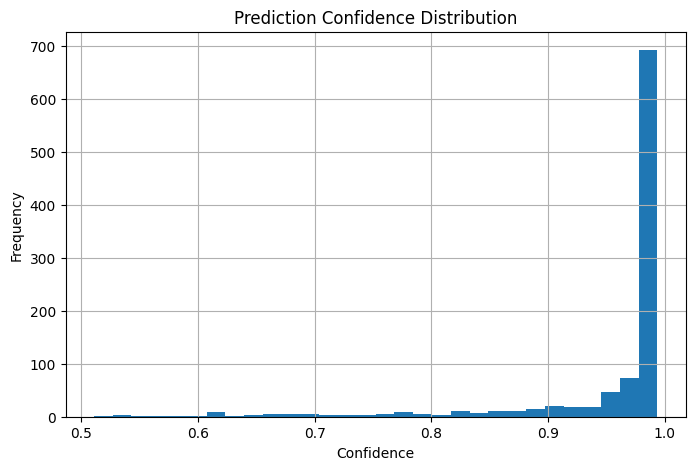


I saw "Night of the Demons 2" first before I saw "Night of the Demons". Unfortunately, my old Blockbuster thought it was a good idea to have the sequel, but no first one. Looney, huh? Now, I think all horror fans need this movie. It's like McDonald's, you know it's bad for you and you'd rather have The Cheesecake Facotory(or whatever pricier restaurant you prefer), but you can't help but just wanting the cheap stuff.<br /><br />Night of the Demons has it all: your innocent, sexy, goes by the rul

True Label: 1
Predicted: 0
Confidence: 0.7829

i was very impressed with this production on likely all levels; from production to plot and character development.<br /><br />this definitely fall under the "realism" genre, since there is nothing going on here that makes use of creative imagination, twists, or manipulating audience in how a viewer shall feel, think and asses.<br /><br />the actors are great, especially the "little" ones. the chemistry between the brother and the sister is mind b

In [11]:
# CELL 9
# Predictions and Confidence Analysis

predictions_output = trainer.predict(
    test_tokenized
)

logits = predictions_output.predictions

probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

predicted_labels = np.argmax(
    logits,
    axis=1
)

confidence_scores = np.max(
    probabilities,
    axis=1
)

plt.figure(
    figsize=(8,5)
)

plt.hist(
    confidence_scores,
    bins=30
)

plt.title(
    "Prediction Confidence Distribution"
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Frequency"
)

plt.grid(True)

confidence_plot_path = (
    ARTIFACT_DIR /
    "confidence_distribution.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

for i in range(5):

    print("\n" + "=" * 80)

    print(
        test_dataset[i]["text"][:500]
    )

    print(
        "\nTrue Label:",
        test_dataset[i]["label"]
    )

    print(
        "Predicted:",
        int(predicted_labels[i])
    )

    print(
        "Confidence:",
        round(
            float(confidence_scores[i]),
            4
        )
    )

##10.EXTRACTION OF SENTENCE EMBEDDINGS

**Explanation for Cell 10**

This cell extracts DistilBERT sentence embeddings and visualizes them using Principal Component Analysis. Positive and negative reviews often form distinct regions in embedding space.

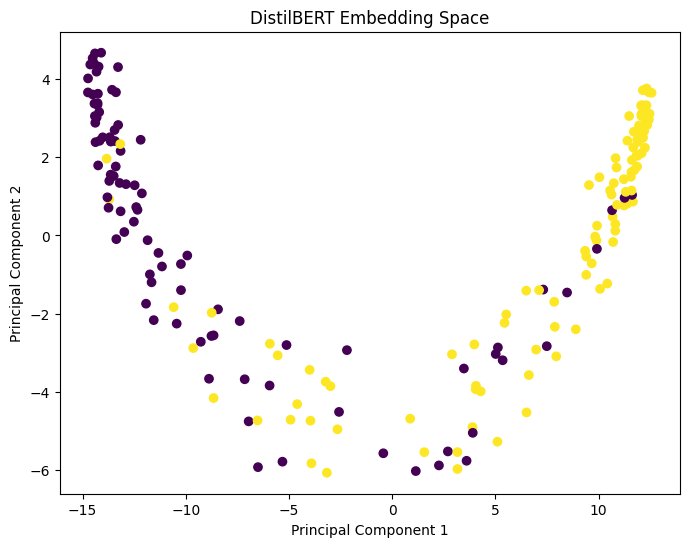

Embedding plot saved: /content/chapter09_distilbert/artifacts/embedding_pca.png


In [12]:
# CELL 10
# Embedding Visualization

from sklearn.decomposition import PCA

sample_texts = [
    test_dataset[i]["text"]
    for i in range(200)
]

sample_labels = [
    test_dataset[i]["label"]
    for i in range(200)
]

inputs = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

base_model = model.distilbert

with torch.no_grad():

    outputs = base_model(
        **inputs
    )

embeddings = (
    outputs.last_hidden_state[:,0,:]
    .cpu()
    .numpy()
)

pca = PCA(
    n_components=2,
    random_state=SEED
)

embeddings_2d = pca.fit_transform(
    embeddings
)

plt.figure(
    figsize=(8,6)
)

scatter = plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=sample_labels
)

plt.title(
    "DistilBERT Embedding Space"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

embedding_plot_path = (
    ARTIFACT_DIR /
    "embedding_pca.png"
)

plt.savefig(
    embedding_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Embedding plot saved:",
    embedding_plot_path
)

##11.SUMMARY AND EXPLANATIONS

**Explanation for Cell 11**

This cell uses GPT-5.2 to explain the results of the Transformer experiment. The response is generated in a structured governance-oriented format separating facts, assumptions, limitations, and recommendations.

In [13]:
# CELL 11
# GPT-5.2 Analysis

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

summary = {
    "model": MODEL_NAME,
    "train_examples": 5000,
    "validation_examples": 1000,
    "test_examples": 1000,
    "evaluation_results": evaluation_results
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this DistilBERT sentiment
classification experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "task": "sentiment_classification",
  "model": "distilbert-base-uncased",
  "data": {
    "train_examples": 5000,
    "validation_examples": 1000,
    "test_examples": 1000,
    "splits": {
      "train_pct": 71.42857142857143,
      "validation_pct": 14.285714285714285,
      "test_pct": 14.285714285714285
    },
    "total_examples": 7000
  },
  "results": {
    "validation": {
      "eval_loss": 0.39247459173202515,
      "eval_accuracy": 0.866,
      "correct_predictions_estimate": 866,
      "incorrect_predictions_estimate": 134,
      "error_rate": 0.134
    }
  },
  "interpretation": {
    "summary": "The model achieves strong validation performance for a small-to-medium fine-tuning set: 86.6% accuracy with a moderate loss (0.392). This suggests the model is learning the task effectively and generalizing reasonably well to held-out data of similar distribution.",
    "what_the_metrics_imply": [
      "Accuracy 0.866 indicates good overall classification performance on the ev

##12.CONCLUSIONS

**Conclusion**

This notebook introduced students to modern Transformer architectures through a practical sentiment classification task. Unlike previous chapters, which focused on architectures built from scratch, this notebook demonstrated how pretrained language models are used in real-world machine learning workflows. This reflects current industry practice, where foundation models are adapted through fine-tuning rather than trained entirely from random initialization.

The DistilBERT model served as an ideal educational bridge between classical deep learning and modern large language models. Students observed how raw text is transformed into tokens, how pretrained Transformer representations are leveraged through transfer learning, and how a model can be adapted to a new task with relatively little additional training. The fine-tuning process illustrated one of the most important ideas in contemporary AI: pretrained knowledge can be reused efficiently across many applications.

Several important concepts were introduced. First, tokenization demonstrated how language must be converted into numerical representations before a Transformer can process it. Second, attention-based representations enabled the model to capture contextual relationships among words. Third, transfer learning allowed the model to adapt existing linguistic knowledge rather than learning language from scratch. Finally, evaluation and embedding visualization provided insight into how the model organizes information internally.

The embedding visualization was particularly important because it revealed how Transformers create meaningful semantic spaces. Reviews with similar sentiment often occupy nearby regions of the embedding space, while reviews with opposing sentiment tend to be separated. This geometric organization of language is one of the reasons Transformer models perform so effectively across diverse tasks.

The notebook also introduced the Hugging Face ecosystem, which has become the dominant platform for modern natural language processing research and deployment. Students learned how datasets, tokenizers, pretrained models, and training utilities integrate into a coherent workflow. These skills are directly transferable to more advanced applications including question answering, summarization, retrieval-augmented generation, and reasoning systems.

Most importantly, this chapter marked the transition from classical machine learning architectures to foundation models. The Transformer architecture introduced here forms the basis of GPT, Claude, Gemini, Llama, and many other contemporary systems. While DistilBERT is much smaller than these large language models, the underlying principles remain the same.

The next chapters will build upon this foundation. Students will explore Graph Neural Networks, Reasoning Models, Retrieval Systems, Agentic Architectures, and Fine-Tuning methodologies. The Transformer serves as the central building block connecting all of these topics. Understanding how it operates is therefore essential for understanding the broader landscape of modern artificial intelligence.